<a href="https://colab.research.google.com/github/olcaykursun/ML/blob/main/Spring2026/pca_on_cnn_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.2MB/s]


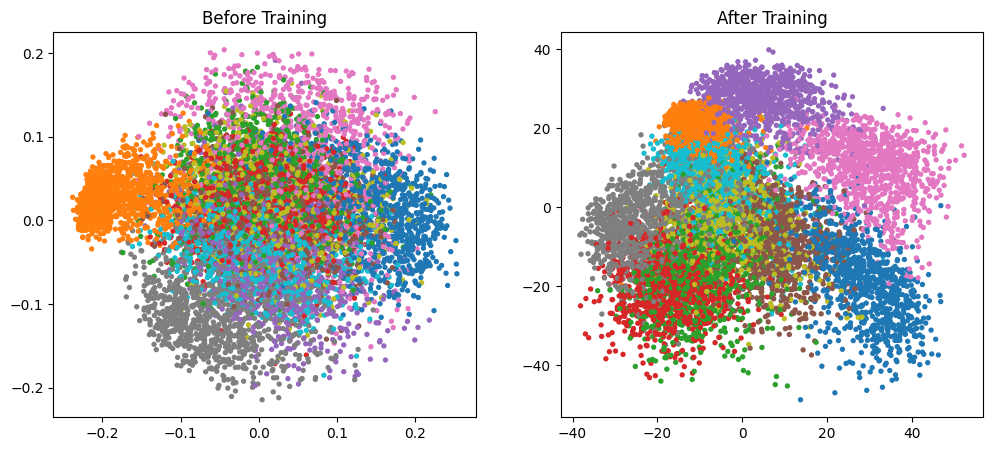

In [ ]:
# ============================================================
# MNIST → CNN → PCA before vs after training
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data ----
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True,
                               download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False,
                               download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ---- Simple CNN ----
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*7*7, 64)  # feature layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x, return_features=False):
        x = self.conv(x)
        x = self.flatten(x)
        features = self.fc1(x)
        x = self.relu(features)
        out = self.fc2(x)

        if return_features:
            return out, features
        return out

model = Net().to(device)

# ---- Function to collect features ----
def get_features():
    model.eval()
    feats = []
    labels = []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            _, f = model(x, return_features=True)
            feats.append(f.cpu())
            labels.append(y)
    return torch.cat(feats).numpy(), torch.cat(labels).numpy()

# ---- Features BEFORE training ----
features_before, labels = get_features()

# ---- Train briefly ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

# ---- Features AFTER training ----
features_after, _ = get_features()

# ---- PCA ----
pca = PCA(n_components=2)

before_2d = pca.fit_transform(features_before)
after_2d  = pca.fit_transform(features_after)

# ---- Plot ----
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(before_2d[:,0], before_2d[:,1], c=labels, cmap='tab10', s=8)
plt.title("Before Training")

plt.subplot(1,2,2)
plt.scatter(after_2d[:,0], after_2d[:,1], c=labels, cmap='tab10', s=8)
plt.title("After Training")

plt.show()

Raw data shape: (10000, 784)
Explained variance (2 components): 0.17592113


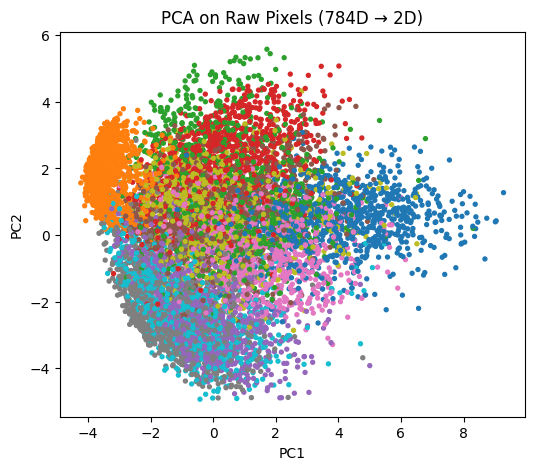

In [ ]:
# ============================================================
# Plain PCA on RAW MNIST pixels
# ============================================================

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ---- Collect raw test images ----
raw_images = []
raw_labels = []

for x, y in test_loader:
    raw_images.append(x.view(x.size(0), -1))  # flatten 28x28 → 784
    raw_labels.append(y)

X_raw = torch.cat(raw_images).numpy()
y_raw = torch.cat(raw_labels).numpy()

print("Raw data shape:", X_raw.shape)  # (10000, 784)

# ---- PCA ----
pca = PCA(n_components=2)
X_raw_2d = pca.fit_transform(X_raw)

print("Explained variance (2 components):",
      pca.explained_variance_ratio_.sum())

# ---- Plot ----
plt.figure(figsize=(6,5))
plt.scatter(X_raw_2d[:,0], X_raw_2d[:,1],
            c=y_raw, cmap='tab10', s=8)
plt.title("PCA on Raw Pixels (784D → 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# ============================================================
# kNN accuracy comparison on 2D PCA spaces
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

def knn_accuracy(X, y, k=5):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    return accuracy_score(y_test, y_pred)

acc_raw    = knn_accuracy(X_raw_2d, y_raw)
acc_before = knn_accuracy(before_2d, labels)
acc_after  = knn_accuracy(after_2d, labels)

print("kNN Accuracy (k=5) on 2D PCA projections:")
print(f"Raw Pixels PCA:            {acc_raw:.4f}")
print(f"CNN Features BEFORE train: {acc_before:.4f}")
print(f"CNN Features AFTER train:  {acc_after:.4f}")

kNN Accuracy (k=5) on 2D PCA projections:
Raw Pixels PCA:            0.4400
CNN Features BEFORE train: 0.4170
CNN Features AFTER train:  0.6413
